# Homework

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

flights = pd.read_csv("/home/log/homework//dataset/flights.csv", low_memory=False)
airlines = pd.read_csv("/home/log/homework//dataset/airlines.csv")
airports = pd.read_csv("/home/log/homework//dataset/airports.csv")

df = flights
df = df.merge(airlines, left_on="AIRLINE", right_on="IATA_CODE")

## Распределение задержек вылета

Исследуем распределение задержек вылета. Это позволит понять,
насколько часто происходят значительные задержки и есть ли
длинный «хвост» больших задержек.

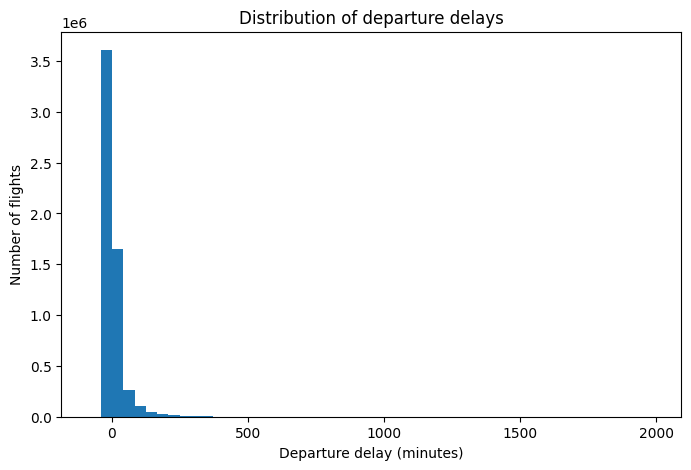

In [9]:
plt.figure(figsize=(8,5))

plt.hist(df["DEPARTURE_DELAY"].dropna(), bins=50)

plt.xlabel("Departure delay (minutes)")
plt.ylabel("Number of flights")
plt.title("Distribution of departure delays")

plt.show()

## Зависимость задержек от дня недели

Проверим гипотезу о неравномерной загрузке аэропортов
в разные дни недели.

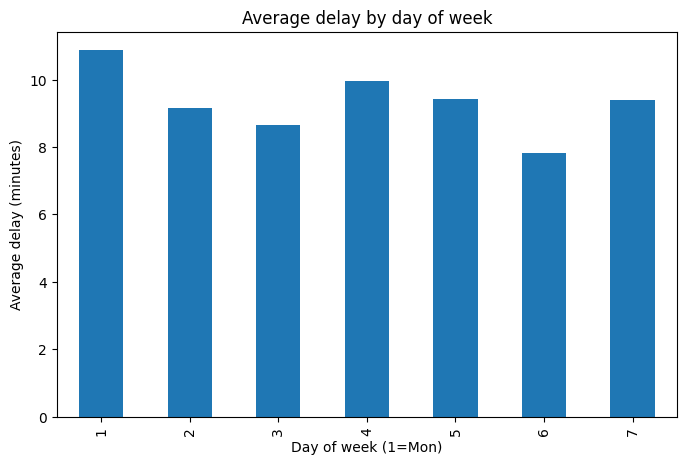

In [10]:
delay_by_day = df.groupby("DAY_OF_WEEK")["DEPARTURE_DELAY"].mean()

plt.figure(figsize=(8,5))
delay_by_day.plot(kind="bar")

plt.xlabel("Day of week (1=Mon)")
plt.ylabel("Average delay (minutes)")
plt.title("Average delay by day of week")

plt.show()

## Причины задержек

Какие причины задержек доминируют?

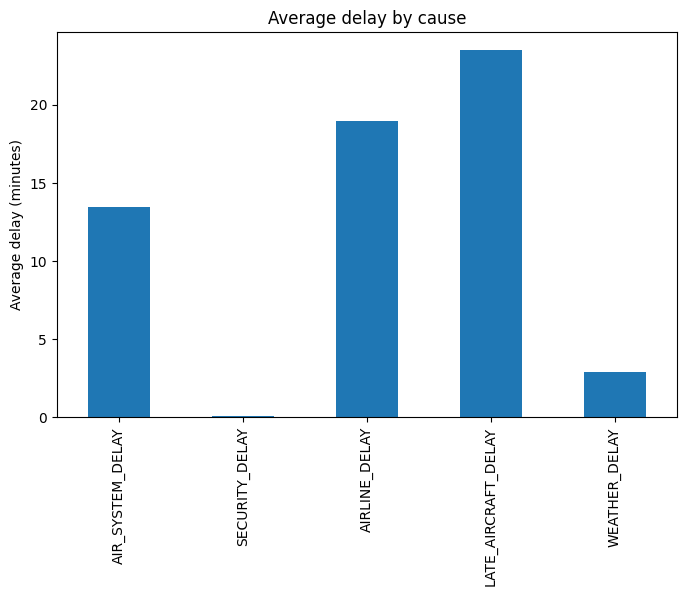

In [11]:
delay_causes = df[
    ["AIR_SYSTEM_DELAY",
     "SECURITY_DELAY",
     "AIRLINE_DELAY",
     "LATE_AIRCRAFT_DELAY",
     "WEATHER_DELAY"]
].mean()

plt.figure(figsize=(8,5))
delay_causes.plot(kind="bar")

plt.ylabel("Average delay (minutes)")
plt.title("Average delay by cause")

plt.show()

## Анализ задержек по авиакомпаниям

Какие авиакомпании проблемные?

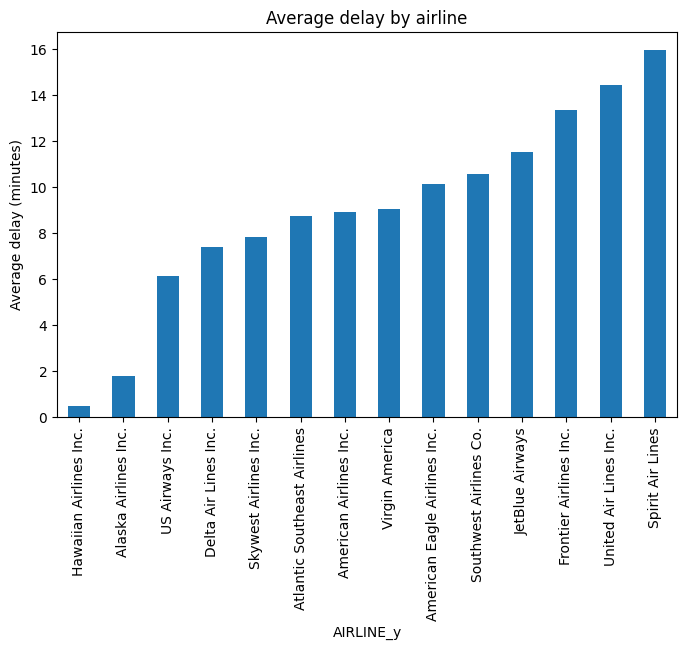

In [12]:
delay_by_airline = df.groupby("AIRLINE_y")["DEPARTURE_DELAY"].mean()

plt.figure(figsize=(8,5))
delay_by_airline.sort_values().plot(kind="bar")

plt.ylabel("Average delay (minutes)")
plt.title("Average delay by airline")

plt.show()

## Связь задержек вылета и прилёта

Проверим, компенсируют ли авиакомпании задержки в пути
или задержка вылета переносится на прилёт.

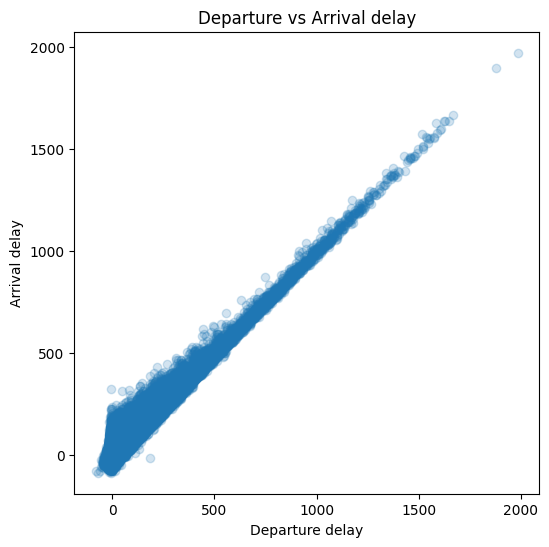

In [13]:
plt.figure(figsize=(6,6))

plt.scatter(df["DEPARTURE_DELAY"], df["ARRIVAL_DELAY"], alpha=0.2)

plt.xlabel("Departure delay")
plt.ylabel("Arrival delay")
plt.title("Departure vs Arrival delay")

plt.show()

## Отмены рейсов

Где чаще отменяют рейсы?

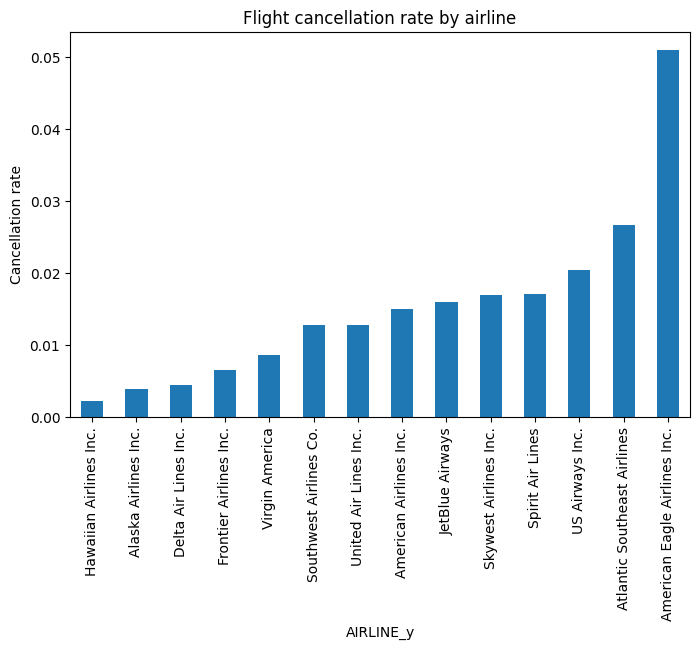

In [14]:
cancel_rate = df.groupby("AIRLINE_y")["CANCELLED"].mean()

plt.figure(figsize=(8,5))
cancel_rate.sort_values().plot(kind="bar")

plt.ylabel("Cancellation rate")
plt.title("Flight cancellation rate by airline")

plt.show()